In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
data = pd.read_csv('processed_data.csv')
data.head()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Credit_Limit_Log,Attrition_Flag,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Education_Level_scaled,Income_Category_scaled,Card_Category_scaled,Gender_scaled
0,768805383,-0.090909,0.5,0.333333,0.5,-1.0,1.0,0.956476,-0.350175,0.988927,2.627193,-1.065558,-0.694444,3.911017,-0.239583,0.699873,0,0.0,1.0,0.0,-0.333333,0.5,0.0,1.0
1,818770008,0.272727,1.5,0.888889,1.0,-1.0,0.0,0.435477,-0.289123,0.459078,3.530702,-1.008702,-0.944444,6.559322,-0.147917,0.406582,0,0.0,0.0,1.0,0.333333,-0.5,0.0,0.0
2,713982108,0.454545,0.5,0.000000,0.0,-1.0,-2.0,-0.132863,-0.895439,-0.006562,6.640351,-0.778186,-1.305556,6.559322,-0.366667,-0.194993,0,0.0,1.0,0.0,0.333333,1.0,0.0,1.0
3,769911858,-0.545455,1.0,-0.222222,-0.5,2.0,-1.0,-0.145198,0.870877,-0.313785,2.934211,-1.055115,-1.305556,6.559322,1.216667,-0.216277,0,0.0,0.0,0.0,-0.333333,-0.5,0.0,0.0
4,709106358,-0.545455,0.5,-1.666667,0.5,-1.0,-2.0,0.019618,-0.895439,0.145527,6.311404,-1.192419,-1.083333,6.559322,-0.366667,0.024594,0,0.0,1.0,0.0,-0.666667,0.5,0.0,1.0


## Feature Selection

In [ ]:
data.drop(columns=['CLIENTNUM',
                   'Months_on_book',
                   'Credit_Limit',
                   'Avg_Open_To_Buy',
                   'Total_Amt_Chng_Q4_Q1',
                   'Total_Trans_Amt'], inplace=True)

#### Feature Importances given by decision trees

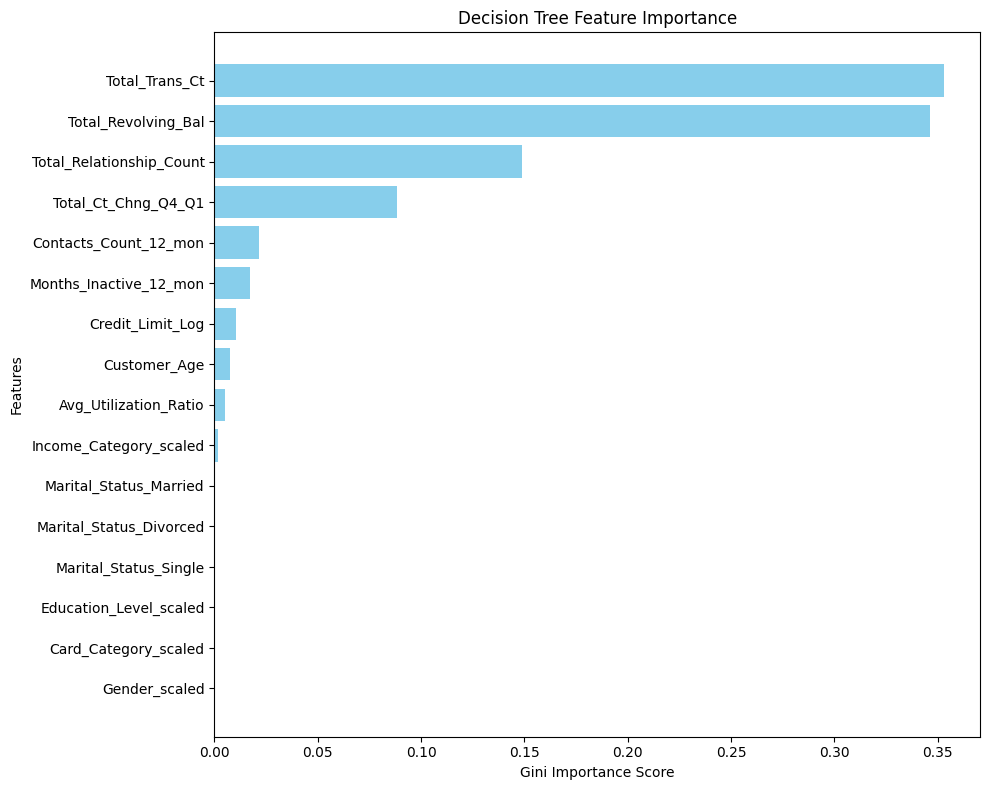

                     Feature  Importance
0             Total_Trans_Ct    0.352890
1        Total_Revolving_Bal    0.346222
2   Total_Relationship_Count    0.148682
3        Total_Ct_Chng_Q4_Q1    0.088194
4      Contacts_Count_12_mon    0.021512
5     Months_Inactive_12_mon    0.017346
6           Credit_Limit_Log    0.010556
7               Customer_Age    0.007736
8      Avg_Utilization_Ratio    0.005241
9     Income_Category_scaled    0.001620
10    Marital_Status_Married    0.000000
11   Marital_Status_Divorced    0.000000
12     Marital_Status_Single    0.000000
13    Education_Level_scaled    0.000000
14      Card_Category_scaled    0.000000
15             Gender_scaled    0.000000


In [5]:
specified_features = [
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Total_Revolving_Bal",
    "Avg_Utilization_Ratio",
    "Total_Relationship_Count",
    "Credit_Limit_Log",
    "Customer_Age",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Marital_Status_Divorced",
    "Marital_Status_Married",
    "Marital_Status_Single",
    "Education_Level_scaled",
    "Income_Category_scaled",
    "Card_Category_scaled",
    "Gender_scaled",
]

X = data[specified_features]
y = data["Attrition_Flag"]

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X, y)

importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": importances}
)

feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"],
    color="skyblue",
)
plt.gca().invert_yaxis()  
plt.xlabel("Gini Importance Score")
plt.ylabel("Features")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

print(feature_importance_df)

**NOTE**<br>
Based on the data exploration phase, we identified and eliminated severe redundancies caused by high collinearity between pairs of features related to transactions, credit limits, and account tenure, always retaining the attribute with the higher linear correlation to the attrition target (Attrition_Flag); additionally, a decision tree feature importance analysis revealed that the remaining demographic and socioeconomic variables provided zero predictive contribution to the model, leading to their complete removal and leaving a final selection composed exclusively of the most robust numerical and behavioral predictors (such as transaction counts, revolving balance, and card utilization ratio)

In [ ]:
data.drop(columns=['Marital_Status_Divorced', 
                   'Marital_Status_Married', 
                   'Marital_Status_Single', 
                   'Dependent_count',
                   'Education_Level_scaled', 
                   'Income_Category_scaled', 
                   'Card_Category_scaled'], inplace=True)
data.head()

,Customer_Age,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Credit_Limit_Log,Attrition_Flag,Gender_scaled
0,-0.090909,0.5,-1.0,1.0,-0.350175,-0.694444,3.911017,-0.239583,0.699873,0,1.0
1,0.272727,1.0,-1.0,0.0,-0.289123,-0.944444,6.559322,-0.147917,0.406582,0,0.0
2,0.454545,0.0,-1.0,-2.0,-0.895439,-1.305556,6.559322,-0.366667,-0.194993,0,1.0
3,-0.545455,-0.5,2.0,-1.0,0.870877,-1.305556,6.559322,1.216667,-0.216277,0,0.0
4,-0.545455,0.5,-1.0,-2.0,-0.895439,-1.083333,6.559322,-0.366667,0.024594,0,1.0


## Modelling

In [7]:
X = data.drop(columns=["Attrition_Flag"])
y = data["Attrition_Flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Define the models to be tested and the hyperparameter combinations for random search
pipeline_config = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=42),
        {"C": [0.001, 0.01, 0.1, 1, 10, 100], "penalty": ["l2"]}
    ),
    "k-Nearest Neighbors (kNN)": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 11, 15, 21], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [3, 5, 10, 15, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4], "criterion": ["gini", "entropy"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [25, 50, 100, 150, 200], "max_depth": [5, 10, 15, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]}
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=42),
        {"n_estimators": [25, 50, 100, 150, 200], "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {"n_estimators": [25, 50, 100, 150, 200], "learning_rate": [0.01, 0.05, 0.1, 0.2], "max_depth": [3, 4, 5, 6]}
    ),
    "Neural Network (MLP)": (
        MLPClassifier(max_iter=1000, random_state=42),
        {"hidden_layer_sizes": [(5, 2), (10, 2), (20,2), (10,3)], "alpha": [0.0001, 0.001, 0.01, 0.1], "learning_rate_init": [0.001, 0.01, 0.1]}
    )
}

# Hyperparameter Search 
test_results = []

for model_name, (estimator, param_grid) in pipeline_config.items():
    print(f"Executing 5-fold cross-validation hyperparameter search for: {model_name}...")
    
    random_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=64,
        scoring="f1_macro",
        cv=5,  # cross-validation that will be applied on the training set
        random_state=42,
        n_jobs=-1
    )
    
    random_search.fit(X_train, y_train)
    
    # Evaluate the best-found model on test set
    y_test_pred = random_search.best_estimator_.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro")
    accuracy = accuracy_score(y_test, y_test_pred)
    
    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1-Score (Macro)": f1
    })

test_results_df = pd.DataFrame(test_results).sort_values(by="F1-Score (Macro)", ascending=False).reset_index(drop=True)

print("\n" + "=" * 65)
print("       FINAL HYPERPARAMETER-TUNED TEST SET PERFORMANCE        ")
print("=" * 65)
print(test_results_df.to_string(index=False))

Executing 5-fold cross-validation hyperparameter search for: Logistic Regression...
Executing 5-fold cross-validation hyperparameter search for: k-Nearest Neighbors (kNN)...
Executing 5-fold cross-validation hyperparameter search for: Decision Tree...
Executing 5-fold cross-validation hyperparameter search for: Random Forest...
Executing 5-fold cross-validation hyperparameter search for: AdaBoost...
Executing 5-fold cross-validation hyperparameter search for: Gradient Boosting...
Executing 5-fold cross-validation hyperparameter search for: Neural Network (MLP)...

       FINAL HYPERPARAMETER-TUNED TEST SET PERFORMANCE        
                    Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
        Gradient Boosting  0.923988           0.880940        0.821569          0.847250
            Random Forest  0.921520           0.879906        0.811388          0.840263
     Neural Network (MLP)  0.912636           0.851772        0.807341          0.827101
          